# TetheredAI MLB Modeling Lab 09 — Leakage-Safe Features, Correlations, and Champion Export

This notebook is the cleaned-up modeling workflow after discovering that `home_score`, `away_score`, `diff_score`, and `home_margin` leaked the game result into the model.

It is intentionally linear:

1. Load the latest feature parquet.
2. Separate **completed/labeled games** from **unresolved rows** and true **scoring candidates**.
3. Audit for leakage before modeling.
4. Build a clean feature list without postgame outcome fields.
5. Handle missingness and high-missing features.
6. Add batted-ball/statcast interaction terms.
7. Chronologically split train/test.
8. Compare models against a constant home-rate baseline.
9. Diagnose calibration and feature importance.
10. Export a champion model bundle only after the leakage checks pass.

Use log loss, Brier score, calibration, and AUC as the primary selection criteria. Accuracy alone is not enough for betting decisions.

In [1]:
from pathlib import Path
from datetime import timedelta
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

# Resolve project root. This works when the notebook is inside notebooks/ or when run from project root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "MLB" / "mlb_betting_app").exists():
    PROJECT_ROOT = PROJECT_ROOT / "MLB" / "mlb_betting_app"

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROCESSED_DIR / "mlb_game_features.parquet"
ODDS_DB_PATH = DATA_DIR / "odds.db"
TARGET_COL = "target_home_win"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("FEATURES_PATH:", FEATURES_PATH)
print("ODDS_DB_PATH:", ODDS_DB_PATH)

PROJECT_ROOT: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app
FEATURES_PATH: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\processed\mlb_game_features.parquet
ODDS_DB_PATH: c:\Users\rfo7799\Desktop\Git\TetheredAI\MLB\mlb_betting_app\data\odds.db


## 1. Load the feature file and verify the date range

The feature file is the source of truth. This cell shows exactly what date range and target coverage you are modeling from.

In [2]:
assert FEATURES_PATH.exists(), f"Missing feature file: {FEATURES_PATH}"

features = pd.read_parquet(FEATURES_PATH)
features = features.copy()

if "official_date" in features.columns:
    features["official_date"] = pd.to_datetime(features["official_date"], errors="coerce")
if "game_datetime_utc" in features.columns:
    features["game_datetime_utc"] = pd.to_datetime(features["game_datetime_utc"], utc=True, errors="coerce")

print("Rows:", len(features))
print("Columns:", len(features.columns))
print("All official_date range:", features["official_date"].min(), "to", features["official_date"].max())

completed_all = features[features[TARGET_COL].notna()].copy()
completed_all[TARGET_COL] = completed_all[TARGET_COL].astype(int)
unresolved_all = features[features[TARGET_COL].isna()].copy()

print("Completed/labeled rows:", len(completed_all))
print("Unresolved rows:", len(unresolved_all))
print("Completed date range:", completed_all["official_date"].min(), "to", completed_all["official_date"].max())
if len(unresolved_all):
    print("Unresolved date range:", unresolved_all["official_date"].min(), "to", unresolved_all["official_date"].max())

bb_cols_preview = [
    c for c in features.columns
    if "batted_ball" in c.lower() or "distance" in c.lower() or "avg_ev" in c.lower()
]
print("Batted-ball/distance columns:", len(bb_cols_preview))
display(pd.Series(bb_cols_preview, name="batted_ball_distance_cols").head(100))

print("Target distribution:")
display(completed_all[TARGET_COL].value_counts(dropna=False).to_frame("count"))

Rows: 9279
Columns: 1800
All official_date range: 2022-08-02 00:00:00 to 2026-09-22 00:00:00
Completed/labeled rows: 9074
Unresolved rows: 205
Completed date range: 2022-08-02 00:00:00 to 2026-06-01 00:00:00
Unresolved date range: 2024-09-29 00:00:00 to 2026-09-22 00:00:00
Batted-ball/distance columns: 57


0                home_team_off_sc_avg_ev_season_to_date
1                         home_team_off_sc_avg_ev_last5
2                        home_team_off_sc_avg_ev_last10
3                        home_team_off_sc_avg_ev_last20
4                        home_team_off_sc_avg_ev_last40
5                away_team_off_sc_avg_ev_season_to_date
6                         away_team_off_sc_avg_ev_last5
7                        away_team_off_sc_avg_ev_last10
8                        away_team_off_sc_avg_ev_last20
9                        away_team_off_sc_avg_ev_last40
10               diff_team_off_sc_avg_ev_season_to_date
11                        diff_team_off_sc_avg_ev_last5
12                       diff_team_off_sc_avg_ev_last10
13                       diff_team_off_sc_avg_ev_last20
14                       diff_team_off_sc_avg_ev_last40
15        home_team_vs_hand_sc_sc_avg_ev_season_to_date
16                home_team_vs_hand_sc_sc_avg_ev_last10
17                home_team_vs_hand_sc_sc_avg_ev

Target distribution:


,count
target_home_win,
1,4816
0,4258


## 2. Distinguish unresolved rows from true upcoming scoring candidates

`target_home_win.isna()` only means **unresolved/unlabeled**. It does not necessarily mean upcoming. Historical postponed/canceled rows and far-future schedule rows can also be unresolved.

In [3]:
AS_OF_DATE = pd.Timestamp.today(tz="America/Chicago").date()
DAYS_FORWARD = 14

features["official_date_dt"] = pd.to_datetime(features["official_date"], errors="coerce").dt.date
unresolved = features[features[TARGET_COL].isna()].copy()

start_date = AS_OF_DATE
end_date = AS_OF_DATE + timedelta(days=DAYS_FORWARD)

date_mask = (
    (unresolved["official_date_dt"] >= start_date) &
    (unresolved["official_date_dt"] <= end_date)
)

status_mask = pd.Series(True, index=unresolved.index)
if "abstract_state" in unresolved.columns:
    status_mask &= unresolved["abstract_state"].astype(str).str.lower().isin(["preview", "live"])
if "detailed_state" in unresolved.columns:
    bad_states = "postponed|cancelled|canceled|suspended|final|completed"
    status_mask &= ~unresolved["detailed_state"].astype(str).str.lower().str.contains(bad_states, na=False)

scoring_candidates = unresolved[date_mask & status_mask].copy()
historical_unresolved = unresolved[unresolved["official_date_dt"] < start_date].copy()
far_future_unresolved = unresolved[unresolved["official_date_dt"] > end_date].copy()

print("AS_OF_DATE:", AS_OF_DATE)
print("Scoring window:", start_date, "to", end_date)
print("Unresolved rows:", len(unresolved))
print("Scoring candidates:", len(scoring_candidates))
print("Historical unresolved:", len(historical_unresolved))
print("Far-future unresolved:", len(far_future_unresolved))

if len(scoring_candidates):
    print("Scoring candidate range:", scoring_candidates["official_date"].min(), "to", scoring_candidates["official_date"].max())
    display(
        scoring_candidates[
            [c for c in [
                "game_pk", "official_date", "game_datetime_utc", "away_team_name", "home_team_name",
                "abstract_state", "detailed_state"
            ] if c in scoring_candidates.columns]
        ].sort_values(["official_date", "game_datetime_utc"]).head(50)
    )
else:
    print("No scoring candidates in the current date window.")

print("Historical unresolved sample:")
display(
    historical_unresolved[
        [c for c in [
            "game_pk", "official_date", "game_datetime_utc", "away_team_name", "home_team_name",
            "abstract_state", "detailed_state"
        ] if c in historical_unresolved.columns]
    ].sort_values(["official_date", "game_datetime_utc"]).head(20)
)

print("Far-future unresolved sample:")
display(
    far_future_unresolved[
        [c for c in [
            "game_pk", "official_date", "game_datetime_utc", "away_team_name", "home_team_name",
            "abstract_state", "detailed_state"
        ] if c in far_future_unresolved.columns]
    ].sort_values(["official_date", "game_datetime_utc"]).head(20)
)

AS_OF_DATE: 2026-06-03
Scoring window: 2026-06-03 to 2026-06-17
Unresolved rows: 205
Scoring candidates: 185
Historical unresolved: 16
Far-future unresolved: 4
Scoring candidate range: 2026-06-03 00:00:00 to 2026-06-16 00:00:00


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state
9094,822727,2026-06-03,2026-06-03 17:05:00+00:00,Miami Marlins,Washington Nationals,Preview,Scheduled
9095,822973,2026-06-03,2026-06-03 17:10:00+00:00,Detroit Tigers,Tampa Bay Rays,Preview,Scheduled
9096,823701,2026-06-03,2026-06-03 17:40:00+00:00,Chicago White Sox,Minnesota Twins,Preview,Scheduled
9097,823130,2026-06-03,2026-06-03 19:40:00+00:00,New York Mets,Seattle Mariners,Preview,Scheduled
9098,823456,2026-06-03,2026-06-03 22:40:00+00:00,San Diego Padres,Philadelphia Phillies,Preview,Scheduled
9099,824755,2026-06-03,2026-06-03 22:45:00+00:00,Baltimore Orioles,Boston Red Sox,Preview,Scheduled
9100,823540,2026-06-03,2026-06-03 23:05:00+00:00,Cleveland Guardians,New York Yankees,Preview,Scheduled
9101,824509,2026-06-03,2026-06-03 23:10:00+00:00,Kansas City Royals,Cincinnati Reds,Preview,Scheduled
9102,824917,2026-06-03,2026-06-03 23:15:00+00:00,Toronto Blue Jays,Atlanta Braves,Preview,Scheduled
9103,823780,2026-06-03,2026-06-03 23:40:00+00:00,San Francisco Giants,Milwaukee Brewers,Preview,Scheduled


Historical unresolved sample:


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state
5743,746577,2024-09-29,2024-09-29 19:10:00+00:00,Houston Astros,Cleveland Guardians,Final,Cancelled
9079,822971,2026-06-02,2026-06-02 22:40:00+00:00,Detroit Tigers,Tampa Bay Rays,Preview,Pre-Game
9080,823460,2026-06-02,2026-06-02 22:40:00+00:00,San Diego Padres,Philadelphia Phillies,Preview,Pre-Game
9081,822728,2026-06-02,2026-06-02 22:45:00+00:00,Miami Marlins,Washington Nationals,Preview,Pre-Game
9082,824754,2026-06-02,2026-06-02 22:45:00+00:00,Baltimore Orioles,Boston Red Sox,Preview,Pre-Game
9083,823541,2026-06-02,2026-06-02 23:05:00+00:00,Cleveland Guardians,New York Yankees,Preview,Pre-Game
9084,824511,2026-06-02,2026-06-02 23:10:00+00:00,Kansas City Royals,Cincinnati Reds,Preview,Pre-Game
9085,824918,2026-06-02,2026-06-02 23:15:00+00:00,Toronto Blue Jays,Atlanta Braves,Preview,Pre-Game
9086,823700,2026-06-02,2026-06-02 23:40:00+00:00,Chicago White Sox,Minnesota Twins,Preview,Pre-Game
9087,823782,2026-06-02,2026-06-02 23:40:00+00:00,San Francisco Giants,Milwaukee Brewers,Preview,Scheduled


Far-future unresolved sample:


,game_pk,official_date,game_datetime_utc,away_team_name,home_team_name,abstract_state,detailed_state
8712,823062,2026-07-07,2026-05-05 23:45:00+00:00,Milwaukee Brewers,St. Louis Cardinals,Final,Postponed
8762,824766,2026-07-17,2026-05-09 20:10:00+00:00,Tampa Bay Rays,Boston Red Sox,Final,Postponed
8966,824514,2026-08-17,2026-05-24 17:40:00+00:00,St. Louis Cardinals,Cincinnati Reds,Final,Postponed
8946,823543,2026-09-22,2026-05-23 17:35:00+00:00,Tampa Bay Rays,New York Yankees,Final,Postponed


## 3. Choose modeling window

The full dataset may include 2022 because the GCP backfill used `DAYS_BACK=1400`. That is okay. Use `MIN_TRAIN_DATE` to control the modeling window.

Set `MIN_TRAIN_DATE = None` to include all labeled rows.

In [4]:
MIN_TRAIN_DATE = "2023-01-01"  # Change to None to include all labeled rows, including 2022.
MAX_TRAIN_DATE = None           # Usually leave as None.

completed = completed_all.copy()

if MIN_TRAIN_DATE is not None:
    completed = completed[completed["official_date"] >= pd.Timestamp(MIN_TRAIN_DATE)].copy()
if MAX_TRAIN_DATE is not None:
    completed = completed[completed["official_date"] <= pd.Timestamp(MAX_TRAIN_DATE)].copy()

completed[TARGET_COL] = completed[TARGET_COL].astype(int)

print("Modeling rows:", len(completed))
print("Modeling date range:", completed["official_date"].min(), "to", completed["official_date"].max())
print("Home win rate:", completed[TARGET_COL].mean())
display(completed[TARGET_COL].value_counts(normalize=True).rename("rate").to_frame())

Modeling rows: 8185
Modeling date range: 2023-03-30 00:00:00 to 2026-06-01 00:00:00
Home win rate: 0.5286499694563226


,rate
target_home_win,
1,0.52865
0,0.47135


## 4. Build candidate feature columns

This first pass identifies numeric columns that could be features. Leakage filtering happens in the next section.

In [5]:
METADATA_COLS = {
    TARGET_COL,
    "game_pk",
    "run_id",
    "scored_at_utc",
    "official_date",
    "official_date_dt",
    "game_datetime_utc",
    "home_team_name",
    "away_team_name",
    "home_team_id",
    "away_team_id",
    "venue_name",
    "abstract_state",
    "detailed_state",
}

# Keep market columns separate. You can test them later, but start with pure-baseball models.
MARKET_TOKENS = [
    "market_", "moneyline", "spread", "total_points", "over_price", "under_price", "book_count", "vig", "implied_prob"
]

def is_market_col(col: str) -> bool:
    low = col.lower()
    return any(tok in low for tok in MARKET_TOKENS)

candidate_feature_cols = [
    c for c in completed.columns
    if c not in METADATA_COLS
    and pd.api.types.is_numeric_dtype(completed[c])
]

market_cols = [c for c in candidate_feature_cols if is_market_col(c)]
statcast_cols = [c for c in candidate_feature_cols if "statcast" in c.lower() or "sc_" in c.lower()]
batted_ball_cols = [
    c for c in candidate_feature_cols
    if "batted_ball" in c.lower() or "distance" in c.lower() or "avg_ev" in c.lower()
]

print("Candidate numeric features:", len(candidate_feature_cols))
print("Market columns:", len(market_cols))
print("Statcast columns:", len(statcast_cols))
print("Batted-ball/distance columns:", len(batted_ball_cols))

Candidate numeric features: 1777
Market columns: 0
Statcast columns: 1092
Batted-ball/distance columns: 57


## 5. Leakage audit and clean feature list

The known leaking columns are:

- `home_score`
- `away_score`
- `diff_score`
- `home_margin`
- `target_home_win`

They define or directly reveal the result. They should be used only for labels/evaluation, never as model features.

In [6]:
LEAKY_COLS_EXACT = {
    "home_score",
    "away_score",
    "diff_score",
    "home_margin",
    "target_home_win",
    # Extra exact names sometimes used in sports datasets.
    "home_runs",
    "away_runs",
    "total_runs",
    "run_total",
    "margin",
}

ROLLING_TOKENS = [
    "_last3", "_last5", "_last10", "_last20", "_last30", "_last40", "_season_to_date", "_pre"
]

HARD_LEAK_PATTERNS = [
    "winner", "winning", "losing", "final", "result", "outcome", "actual", "post_"
]


def is_probably_leaky_feature(col: str) -> bool:
    c = col.lower()

    if c in LEAKY_COLS_EXACT:
        return True

    if any(p in c for p in HARD_LEAK_PATTERNS):
        return True

    # Raw same-game boxscore columns are suspicious unless they are explicitly rolling/pregame.
    # Example to drop: home_team_box_runs
    # Example to keep: home_team_box_runs_last20 or home_team_box_runs_season_to_date
    if c.startswith(("home_team_box_", "away_team_box_", "diff_team_box_")):
        if not any(tok in c for tok in ROLLING_TOKENS):
            return True

    # Raw identifiers should not be model inputs.
    if c.endswith("_id") or c in {"game_pk"}:
        return True

    return False

hard_suspects = [c for c in candidate_feature_cols if c.lower() in LEAKY_COLS_EXACT or any(p in c.lower() for p in HARD_LEAK_PATTERNS)]
same_game_box_suspects = [
    c for c in candidate_feature_cols
    if c.lower().startswith(("home_team_box_", "away_team_box_", "diff_team_box_"))
    and not any(tok in c.lower() for tok in ROLLING_TOKENS)
]

print("Hard leakage suspects:", len(hard_suspects))
display(pd.Series(hard_suspects, name="hard_leakage_suspects").head(200))

print("Potential same-game boxscore suspects:", len(same_game_box_suspects))
display(pd.Series(same_game_box_suspects, name="same_game_boxscore_suspects").head(250))

leakage_removed_cols = sorted([c for c in candidate_feature_cols if is_probably_leaky_feature(c)])
feature_cols_no_leak = [c for c in candidate_feature_cols if c not in leakage_removed_cols]

print("Candidate features:", len(candidate_feature_cols))
print("Removed by leakage filter:", len(leakage_removed_cols))
print("After leakage filter:", len(feature_cols_no_leak))
display(pd.Series(leakage_removed_cols, name="removed_by_leakage_filter").head(300))

Hard leakage suspects: 5


0     home_score
1     away_score
2    home_margin
3     total_runs
4     diff_score
Name: hard_leakage_suspects, dtype: object

Potential same-game boxscore suspects: 27


0       home_team_box_games_to_date
1                 home_team_box_xbh
2           home_team_box_bb_per_ab
3            home_team_box_k_per_ab
4           home_team_box_hr_per_ab
5         home_team_box_xbh_per_hit
6         home_team_box_sb_attempts
7     home_team_box_sb_success_rate
8         home_team_box_lob_per_run
9       away_team_box_games_to_date
10                away_team_box_xbh
11          away_team_box_bb_per_ab
12           away_team_box_k_per_ab
13          away_team_box_hr_per_ab
14        away_team_box_xbh_per_hit
15        away_team_box_sb_attempts
16    away_team_box_sb_success_rate
17        away_team_box_lob_per_run
18      diff_team_box_games_to_date
19                diff_team_box_xbh
20          diff_team_box_bb_per_ab
21           diff_team_box_k_per_ab
22          diff_team_box_hr_per_ab
23        diff_team_box_xbh_per_hit
24        diff_team_box_sb_attempts
25    diff_team_box_sb_success_rate
26        diff_team_box_lob_per_run
Name: same_game_boxscore_sus

Candidate features: 1777
Removed by leakage filter: 36
After leakage filter: 1741


0                        away_score
1           away_team_box_bb_per_ab
2       away_team_box_games_to_date
3           away_team_box_hr_per_ab
4            away_team_box_k_per_ab
5         away_team_box_lob_per_run
6         away_team_box_sb_attempts
7     away_team_box_sb_success_rate
8                 away_team_box_xbh
9         away_team_box_xbh_per_hit
10                       diff_score
11          diff_team_box_bb_per_ab
12      diff_team_box_games_to_date
13          diff_team_box_hr_per_ab
14           diff_team_box_k_per_ab
15        diff_team_box_lob_per_run
16        diff_team_box_sb_attempts
17    diff_team_box_sb_success_rate
18                diff_team_box_xbh
19        diff_team_box_xbh_per_hit
20                     diff_team_id
21                      home_margin
22                       home_score
23          home_team_box_bb_per_ab
24      home_team_box_games_to_date
25          home_team_box_hr_per_ab
26           home_team_box_k_per_ab
27        home_team_box_lob_

### Single-feature leakage test

This identifies features that predict the target suspiciously well by themselves. Anything above ~0.90 single-feature AUC deserves inspection. The known leaking score columns should disappear after cleaning.

In [7]:
def single_feature_auc_table(df: pd.DataFrame, cols: list[str], target_col: str = TARGET_COL) -> pd.DataFrame:
    y = df[target_col].astype(int)
    rows = []
    for c in cols:
        if c not in df.columns or not pd.api.types.is_numeric_dtype(df[c]):
            continue
        tmp = pd.DataFrame({"x": df[c], "y": y}).dropna()
        if tmp["x"].nunique() < 2 or tmp["y"].nunique() < 2:
            continue
        try:
            auc = roc_auc_score(tmp["y"], tmp["x"])
            auc = max(auc, 1 - auc)
            rows.append((c, auc, len(tmp), tmp["x"].nunique()))
        except Exception:
            pass
    return pd.DataFrame(rows, columns=["feature", "single_feature_auc", "n", "n_unique"]).sort_values(
        "single_feature_auc", ascending=False
    )

print("Top single-feature AUC BEFORE leakage cleaning:")
single_auc_before = single_feature_auc_table(completed, candidate_feature_cols)
display(single_auc_before.head(100))

print("Top single-feature AUC AFTER leakage cleaning:")
single_auc_after = single_feature_auc_table(completed, feature_cols_no_leak)
display(single_auc_after.head(100))

suspicious_after = single_auc_after[single_auc_after["single_feature_auc"] >= 0.90]
if len(suspicious_after):
    print("WARNING: suspicious high-AUC features remain after leakage cleaning.")
    display(suspicious_after)
else:
    print("No single feature above 0.90 AUC after leakage cleaning.")

Top single-feature AUC BEFORE leakage cleaning:


,feature,single_feature_auc,n,n_unique
4,home_margin,1.000000,8185,41
842,diff_score,1.000000,8185,41
3,away_score,0.856657,8185,24
2,home_score,0.824963,8185,22
500,diff_run_diff_season_to_date,0.579553,8185,8161
485,diff_win_season_to_date,0.577302,8185,8050
495,diff_runs_against_season_to_date,0.574241,8185,8156
55,elo_home_win_prob,0.570079,8185,8185
54,diff_elo_pre,0.570079,8185,8185
1712,diff_bullpen_sc_woba_allowed_season_to_date,0.569728,8185,8183


Top single-feature AUC AFTER leakage cleaning:


,feature,single_feature_auc,n,n_unique
466,diff_run_diff_season_to_date,0.579553,8185,8161
451,diff_win_season_to_date,0.577302,8185,8050
461,diff_runs_against_season_to_date,0.574241,8185,8156
48,elo_home_win_prob,0.570079,8185,8185
47,diff_elo_pre,0.570079,8185,8185
1676,diff_bullpen_sc_woba_allowed_season_to_date,0.569728,8185,8183
244,diff_team_box_walks_season_to_date,0.567004,8185,8131
814,diff_team_off_sc_pitches_seen_season_to_date,0.566918,8185,8179
284,diff_team_box_bb_per_ab_season_to_date,0.564791,8185,8185
879,diff_team_off_sc_bb_rate_season_to_date,0.564632,8185,8185


No single feature above 0.90 AUC after leakage cleaning.


## 6. Missingness handling

Rules:

- Drop very-high-missing features above `DROP_IF_MISSING_GT`.
- Drop stolen-base success-rate features because missingness is denominator-driven and unstable.
- Keep moderate-missing starter Statcast features; the model pipeline uses median imputation plus missing indicators.

In [8]:
DROP_IF_MISSING_GT = 0.35
MANUAL_DROP_CONTAINS = ["sb_success_rate"]

missing_pct = completed[feature_cols_no_leak].isna().mean().sort_values(ascending=False)
missing_summary = missing_pct.to_frame("missing_pct")
print("Top missingness after leakage filtering:")
display(missing_summary.head(100))

drop_high_missing = missing_pct[missing_pct > DROP_IF_MISSING_GT].index.tolist()
manual_drop = [c for c in feature_cols_no_leak if any(token in c.lower() for token in MANUAL_DROP_CONTAINS)]

missing_removed_cols = sorted(set(drop_high_missing + manual_drop))
feature_cols_clean = [c for c in feature_cols_no_leak if c not in missing_removed_cols]

print("Removed for missingness/manual rules:", len(missing_removed_cols))
display(pd.Series(missing_removed_cols, name="removed_missing_or_manual").head(300))
print("Clean feature count:", len(feature_cols_clean))

Top missingness after leakage filtering:


,missing_pct
diff_team_box_sb_success_rate_last3,0.209041
home_team_box_sb_success_rate_last3,0.114356
away_team_box_sb_success_rate_last3,0.106292
diff_team_box_sb_success_rate_last5,0.060110
diff_starter_hr_per_9_last10,0.055834
diff_starter_k_minus_bb_per_bf_last10,0.055834
diff_starter_ip_per_start_last10,0.055834
diff_starter_games_to_date,0.055834
diff_starter_pitches_per_start_last10,0.055834
diff_starter_days_since_last_start,0.055834


Removed for missingness/manual rules: 15


0             away_team_box_sb_success_rate_last10
1             away_team_box_sb_success_rate_last20
2              away_team_box_sb_success_rate_last3
3              away_team_box_sb_success_rate_last5
4     away_team_box_sb_success_rate_season_to_date
5             diff_team_box_sb_success_rate_last10
6             diff_team_box_sb_success_rate_last20
7              diff_team_box_sb_success_rate_last3
8              diff_team_box_sb_success_rate_last5
9     diff_team_box_sb_success_rate_season_to_date
10            home_team_box_sb_success_rate_last10
11            home_team_box_sb_success_rate_last20
12             home_team_box_sb_success_rate_last3
13             home_team_box_sb_success_rate_last5
14    home_team_box_sb_success_rate_season_to_date
Name: removed_missing_or_manual, dtype: object

Clean feature count: 1726


## 7. Correlation diagnostics on clean features

Correlation is a diagnostic, not a final model selector. It helps find redundant signals, broken features, and interaction candidates.

In [9]:
numeric_clean = completed[feature_cols_clean].select_dtypes(include="number").copy()

corr_to_target = (
    numeric_clean.assign(target_home_win=completed[TARGET_COL].values)
    .corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL)
    .dropna()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top absolute correlations to target:")
display(corr_to_target.head(80).to_frame("corr_to_home_win"))

print("Most positive correlations:")
display(corr_to_target.sort_values(ascending=False).head(50).to_frame("corr_to_home_win"))

print("Most negative correlations:")
display(corr_to_target.sort_values(ascending=True).head(50).to_frame("corr_to_home_win"))

Top absolute correlations to target:


,corr_to_home_win
diff_run_diff_season_to_date,0.143138
diff_win_season_to_date,0.137470
diff_runs_against_season_to_date,-0.135021
diff_elo_pre,0.128517
elo_home_win_prob,0.127165
diff_bullpen_sc_woba_allowed_season_to_date,-0.122224
diff_team_off_sc_pitches_seen_season_to_date,0.119915
diff_team_box_walks_season_to_date,0.119144
diff_team_box_bb_per_ab_season_to_date,0.114973
diff_team_off_sc_bb_rate_season_to_date,0.114382


Most positive correlations:


,corr_to_home_win
diff_run_diff_season_to_date,0.143138
diff_win_season_to_date,0.137470
diff_elo_pre,0.128517
elo_home_win_prob,0.127165
diff_team_off_sc_pitches_seen_season_to_date,0.119915
diff_team_box_walks_season_to_date,0.119144
diff_team_box_bb_per_ab_season_to_date,0.114973
diff_team_off_sc_bb_rate_season_to_date,0.114382
diff_team_box_runs_season_to_date,0.112448
diff_runs_for_season_to_date,0.112448


Most negative correlations:


,corr_to_home_win
diff_runs_against_season_to_date,-0.135021
diff_bullpen_sc_woba_allowed_season_to_date,-0.122224
away_run_diff_season_to_date,-0.102558
away_win_season_to_date,-0.101168
home_runs_against_season_to_date,-0.098374
diff_bullpen_sc_bb_rate_season_to_date,-0.096411
away_elo_pre,-0.096103
home_bullpen_sc_woba_allowed_season_to_date,-0.090889
diff_runs_against_last20,-0.084899
diff_starter_statcast_sc_woba_allowed_season_to_date,-0.082954


In [10]:
TOP_N_FOR_REDUNDANCY = 120
corr_features = corr_to_target.abs().head(TOP_N_FOR_REDUNDANCY).index.tolist()

if len(corr_features) >= 2:
    corr_abs = numeric_clean[corr_features].corr(numeric_only=True).abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    high_corr_pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
        .sort_values("abs_corr", ascending=False)
    )
    display(high_corr_pairs.head(120))
else:
    print("Not enough features for redundancy table.")

,feature_1,feature_2,abs_corr
1145,diff_team_box_runs_season_to_date,diff_runs_for_season_to_date,1.000000
6437,away_team_box_runs_season_to_date,away_runs_for_season_to_date,1.000000
5249,home_runs_for_season_to_date,home_team_box_runs_season_to_date,1.000000
6105,diff_team_box_runs_last20,diff_runs_for_last20,0.999821
7063,diff_runs_for_last10,diff_team_box_runs_last10,0.999726
6402,away_team_box_bb_per_ab_season_to_date,away_team_off_sc_bb_rate_season_to_date,0.998500
4794,home_team_off_sc_bb_rate_season_to_date,home_team_box_bb_per_ab_season_to_date,0.998439
924,diff_team_box_bb_per_ab_season_to_date,diff_team_off_sc_bb_rate_season_to_date,0.998435
354,diff_elo_pre,elo_home_win_prob,0.998426
2862,diff_team_box_ops_season_to_date,diff_team_vs_hand_ops_season_to_date,0.997376


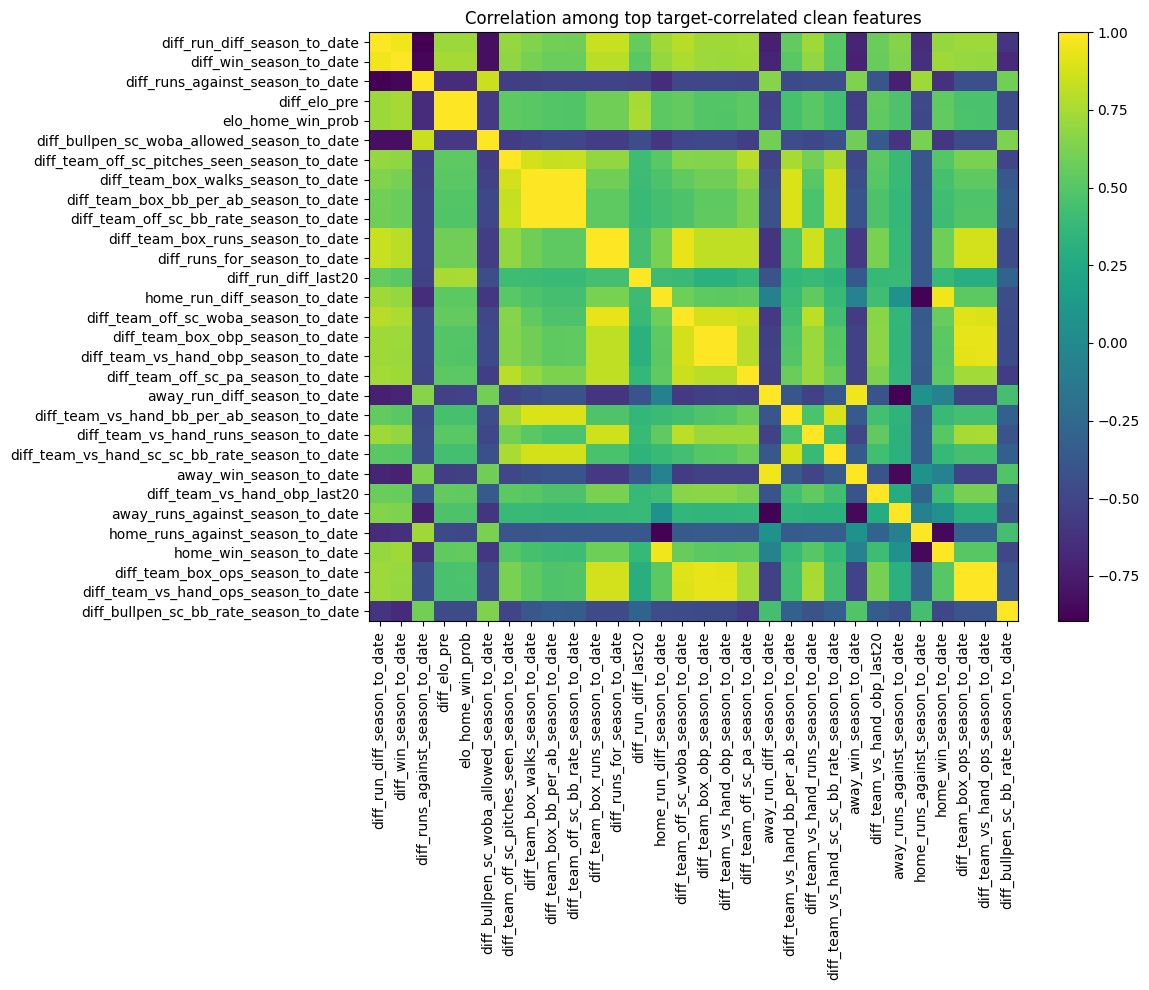

In [11]:
heatmap_features = corr_to_target.abs().head(30).index.tolist()

if len(heatmap_features) >= 2:
    mat = numeric_clean[heatmap_features].corr(numeric_only=True)
    plt.figure(figsize=(12, 10))
    plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(heatmap_features)), heatmap_features, rotation=90)
    plt.yticks(range(len(heatmap_features)), heatmap_features)
    plt.colorbar()
    plt.title("Correlation among top target-correlated clean features")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough heatmap features.")

## 8. Add baseball-logical interaction terms

These are deliberately limited. Promote interactions only if they improve holdout log loss/Brier and calibration.

In [12]:
def add_interaction_terms(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    out = df.copy()
    created = []

    specs = [
        # Team contact quality × starter contact allowed.
        ("diff_team_off_sc_avg_batted_ball_ev_last20", "diff_starter_statcast_sc_avg_batted_ball_ev_allowed_last10", "int_team_ev_x_starter_ev_allowed"),
        ("diff_team_off_sc_avg_batted_ball_distance_last20", "diff_starter_statcast_sc_avg_batted_ball_distance_allowed_last10", "int_team_dist_x_starter_dist_allowed"),
        ("diff_team_off_sc_barrel_rate_last20", "diff_starter_statcast_sc_barrel_rate_allowed_last10", "int_team_barrel_x_starter_barrel_allowed"),
        ("diff_team_off_sc_hard_hit_rate_last20", "diff_starter_statcast_sc_hard_hit_rate_allowed_last10", "int_team_hardhit_x_starter_hardhit_allowed"),

        # Platoon offense × starter skill.
        ("diff_team_vs_hand_ops_last20", "diff_starter_k_minus_bb_per_bf_last10", "int_vs_hand_ops_x_starter_kbb"),
        ("diff_team_vs_hand_sc_sc_woba_last20", "diff_starter_statcast_sc_woba_allowed_last10", "int_vs_hand_woba_x_starter_woba_allowed"),

        # Bullpen quality/fatigue × opponent contact.
        ("diff_bullpen_sc_woba_allowed_last20", "diff_team_off_sc_hard_hit_rate_last20", "int_bullpen_woba_x_team_hardhit"),
        ("diff_sc_bullpen_pitches_last3", "diff_team_off_sc_barrel_rate_last20", "int_bullpen_work_x_team_barrel"),

        # ELO/team strength × starter edge.
        ("diff_elo_pre", "diff_starter_statcast_sc_k_rate_last20", "int_elo_x_starter_k_rate"),
        ("elo_home_win_prob", "diff_starter_statcast_sc_woba_allowed_last20", "int_elo_prob_x_starter_woba_allowed"),
    ]

    for a, b, new_col in specs:
        if a in out.columns and b in out.columns:
            out[new_col] = out[a] * out[b]
            created.append(new_col)

    return out, created

features_i, interaction_cols = add_interaction_terms(features)
completed_i = features_i.loc[completed.index].copy()

# Only keep interactions that are numeric and non-leaky by construction.
interaction_cols = [c for c in interaction_cols if c in completed_i.columns and pd.api.types.is_numeric_dtype(completed_i[c])]
feature_cols_with_interactions = feature_cols_clean + interaction_cols

print("Created interaction columns:", len(interaction_cols))
display(pd.Series(interaction_cols, name="interaction_cols"))
print("Feature count with interactions:", len(feature_cols_with_interactions))

Created interaction columns: 7


0      int_team_barrel_x_starter_barrel_allowed
1    int_team_hardhit_x_starter_hardhit_allowed
2                 int_vs_hand_ops_x_starter_kbb
3       int_vs_hand_woba_x_starter_woba_allowed
4                int_bullpen_work_x_team_barrel
5                      int_elo_x_starter_k_rate
6           int_elo_prob_x_starter_woba_allowed
Name: interaction_cols, dtype: object

Feature count with interactions: 1733


## 9. Chronological train/test split and baseline

Do not drop columns from the split dataframe. Keep the target available, and control model inputs through `clean_feature_cols` / `feature_cols_with_interactions`.

In [13]:
def chronological_split(df: pd.DataFrame, test_frac: float = 0.20):
    sort_cols = [c for c in ["official_date", "game_datetime_utc", "game_pk"] if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_frac))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = chronological_split(completed_i, test_frac=0.20)

print("Train rows:", len(train_df), train_df["official_date"].min(), "to", train_df["official_date"].max())
print("Test rows:", len(test_df), test_df["official_date"].min(), "to", test_df["official_date"].max())

y_train = train_df[TARGET_COL].astype(int)
y_test = test_df[TARGET_COL].astype(int)

baseline_train_rate = y_train.mean()
baseline_probs = np.repeat(baseline_train_rate, len(y_test))

baseline_metrics = {
    "model_name": "constant_train_home_rate",
    "feature_count": 0,
    "n_test": len(y_test),
    "avg_pred": float(baseline_probs.mean()),
    "actual_rate": float(y_test.mean()),
    "log_loss": float(log_loss(y_test, baseline_probs)),
    "brier": float(brier_score_loss(y_test, baseline_probs)),
    "roc_auc": 0.5,
    "accuracy_50pct": float(accuracy_score(y_test, baseline_probs >= 0.5)),
    "suspicious_metric": False,
}

display(pd.DataFrame([baseline_metrics]))

Train rows: 6548 2023-03-30 00:00:00 to 2025-08-04 00:00:00
Test rows: 1637 2025-08-04 00:00:00 to 2026-06-01 00:00:00


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,constant_train_home_rate,0,1637,0.528406,0.529627,0.691394,0.249124,0.5,0.529627,False


## 10. Model feature sets

`baseline_no_market` now means **cleaned, non-market, non-leaky** features. It should not contain score/margin/result columns.

In [14]:
def cols_matching(cols, include_any=(), exclude_any=()):
    out = []
    for c in cols:
        low = c.lower()
        if include_any and not any(x in low for x in include_any):
            continue
        if exclude_any and any(x in low for x in exclude_any):
            continue
        out.append(c)
    return out

pure_base_cols = [c for c in feature_cols_clean if c not in market_cols]
pure_base_cols_i = [c for c in feature_cols_with_interactions if c not in market_cols]

feature_sets = {
    "baseline_no_market_clean": pure_base_cols,
    "enhanced_with_interactions_clean": pure_base_cols_i,
    "batted_ball_only": cols_matching(
        pure_base_cols_i,
        include_any=("batted_ball", "avg_ev", "max_ev", "p90_batted", "distance", "hard_hit", "barrel")
    ),
    "statcast_only": [c for c in pure_base_cols_i if (c in statcast_cols or c in interaction_cols)],
    "starter_statcast": cols_matching(pure_base_cols_i, include_any=("starter_statcast",)),
    "team_statcast": cols_matching(pure_base_cols_i, include_any=("team_off_sc", "team_vs_hand_sc")),
    "starter_plus_elo": sorted(set(cols_matching(pure_base_cols_i, include_any=("starter",)) + cols_matching(pure_base_cols_i, include_any=("elo",)))),
}

# Remove empty or tiny feature sets.
feature_sets = {k: v for k, v in feature_sets.items() if len(v) >= 5}

for name, cols in feature_sets.items():
    bad = [c for c in cols if c not in train_df.columns]
    assert not bad, f"{name} has missing columns: {bad[:10]}"
    leaked = [c for c in cols if is_probably_leaky_feature(c)]
    assert not leaked, f"{name} has leaky columns: {leaked[:20]}"

summary = pd.DataFrame([{"feature_set": k, "feature_count": len(v)} for k, v in feature_sets.items()])
display(summary)

,feature_set,feature_count
0,baseline_no_market_clean,1726
1,enhanced_with_interactions_clean,1733
2,batted_ball_only,215
3,statcast_only,1099
4,starter_statcast,390
5,team_statcast,432
6,starter_plus_elo,508


## 11. Define models

SVM is included as optional because it can be slow with thousands of features. Set `RUN_SVM = True` if you want to test it.

In [15]:
def make_pipeline(model, scale=False):
    steps = [("imputer", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "logit_l2": make_pipeline(LogisticRegression(max_iter=5000, C=0.5, solver="lbfgs"), scale=True),
    "random_forest": make_pipeline(RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )),
    "extra_trees": make_pipeline(ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=25,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )),
    "hist_gbdt": make_pipeline(HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=42,
    )),
}

try:
    from xgboost import XGBClassifier
    models["xgboost"] = make_pipeline(XGBClassifier(
        n_estimators=300,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_alpha=0.0,
        reg_lambda=2.0,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    ))
except Exception as e:
    print("XGBoost unavailable:", e)

try:
    from lightgbm import LGBMClassifier
    models["lightgbm"] = make_pipeline(LGBMClassifier(
        n_estimators=400,
        max_depth=3,
        learning_rate=0.02,
        subsample=0.9,
        colsample_bytree=0.8,
        min_child_samples=50,
        reg_alpha=0.0,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ))
except Exception as e:
    print("LightGBM unavailable:", e)

RUN_SVM = False
if RUN_SVM:
    from sklearn.svm import SVC
    models["svm_rbf"] = make_pipeline(SVC(C=1.0, kernel="rbf", probability=True, random_state=42), scale=True)

print("Models:", list(models.keys()))

Models: ['logit_l2', 'random_forest', 'extra_trees', 'hist_gbdt', 'xgboost', 'lightgbm']


## 12. Fit and evaluate model grid

The suspicious-metric flag catches impossible-looking results. If you see AUC/accuracy near 1.0 or log loss near zero, stop and rerun leakage audit.

In [16]:
def evaluate_model(name, model, cols):
    X_train = train_df[cols].copy()
    X_test = test_df[cols].copy()

    fitted = clone(model)
    fitted.fit(X_train, y_train)

    if hasattr(fitted, "predict_proba"):
        p = fitted.predict_proba(X_test)[:, 1]
    else:
        raw = fitted.decision_function(X_test)
        p = 1 / (1 + np.exp(-raw))

    p = np.clip(p, 1e-6, 1 - 1e-6)
    pred = (p >= 0.5).astype(int)

    metrics = {
        "model_name": name,
        "feature_count": len(cols),
        "n_test": len(y_test),
        "avg_pred": float(np.mean(p)),
        "actual_rate": float(y_test.mean()),
        "log_loss": float(log_loss(y_test, p)),
        "brier": float(brier_score_loss(y_test, p)),
        "roc_auc": float(roc_auc_score(y_test, p)),
        "accuracy_50pct": float(accuracy_score(y_test, pred)),
    }

    metrics["suspicious_metric"] = bool(
        metrics["roc_auc"] >= 0.95 or
        metrics["accuracy_50pct"] >= 0.90 or
        metrics["log_loss"] <= 0.25
    )
    return fitted, p, metrics

results = [baseline_metrics]
fitted_models = {}
preds_by_name = {}

for fs_name, cols in feature_sets.items():
    if len(cols) == 0:
        continue

    for model_name, model in models.items():
        full_name = f"{fs_name}__{model_name}"
        try:
            fitted, p, metrics = evaluate_model(full_name, model, cols)
            results.append(metrics)
            fitted_models[full_name] = (fitted, cols)
            preds_by_name[full_name] = p
            print("finished", full_name, metrics)
        except Exception as e:
            print("FAILED", full_name, repr(e))

results_df = pd.DataFrame(results).sort_values(["suspicious_metric", "log_loss", "brier"]).reset_index(drop=True)
display(results_df)

if results_df["suspicious_metric"].any():
    print("WARNING: At least one model produced suspiciously strong metrics. Do not export those models.")
    display(results_df[results_df["suspicious_metric"]])

finished baseline_no_market_clean__logit_l2 {'model_name': 'baseline_no_market_clean__logit_l2', 'feature_count': 1726, 'n_test': 1637, 'avg_pred': 0.5469595452942159, 'actual_rate': 0.529627367135003, 'log_loss': 0.7973367382447774, 'brier': 0.2836413444012219, 'roc_auc': 0.5556434338441258, 'accuracy_50pct': 0.5357361026267563, 'suspicious_metric': False}
finished baseline_no_market_clean__random_forest {'model_name': 'baseline_no_market_clean__random_forest', 'feature_count': 1726, 'n_test': 1637, 'avg_pred': 0.535445367964048, 'actual_rate': 0.529627367135003, 'log_loss': 0.6825814104442286, 'brier': 0.24481751609889624, 'roc_auc': 0.5688221812789287, 'accuracy_50pct': 0.5577275503970678, 'suspicious_metric': False}
finished baseline_no_market_clean__extra_trees {'model_name': 'baseline_no_market_clean__extra_trees', 'feature_count': 1726, 'n_test': 1637, 'avg_pred': 0.5343564550098192, 'actual_rate': 0.529627367135003, 'log_loss': 0.682016389845507, 'brier': 0.2445167868326649, 'r

,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,statcast_only__xgboost,1099,1637,0.537137,0.529627,0.681427,0.244242,0.577888,0.565669,False
1,statcast_only__random_forest,1099,1637,0.534118,0.529627,0.681705,0.244388,0.573602,0.553451,False
2,baseline_no_market_clean__extra_trees,1726,1637,0.534356,0.529627,0.682016,0.244517,0.576409,0.564447,False
3,enhanced_with_interactions_clean__random_forest,1733,1637,0.533813,0.529627,0.682138,0.244595,0.570781,0.562615,False
4,baseline_no_market_clean__random_forest,1726,1637,0.535445,0.529627,0.682581,0.244818,0.568822,0.557728,False
5,enhanced_with_interactions_clean__extra_trees,1733,1637,0.534245,0.529627,0.682594,0.244798,0.573687,0.557117,False
6,statcast_only__extra_trees,1099,1637,0.532351,0.529627,0.683267,0.245119,0.571653,0.554673,False
7,enhanced_with_interactions_clean__xgboost,1733,1637,0.536351,0.529627,0.683359,0.245155,0.571764,0.554062,False
8,starter_plus_elo__xgboost,508,1637,0.525797,0.529627,0.683670,0.245295,0.571818,0.562615,False
9,starter_plus_elo__random_forest,508,1637,0.525372,0.529627,0.683896,0.245441,0.566578,0.544288,False


## 13. Champion diagnostics

This selects the best non-suspicious trained model by log loss. The constant baseline is not exportable.

In [30]:
# Pick top 3 eligible models by log_loss, then Brier as tie-breaker
eligible = results_df[
    (~results_df["suspicious_metric"]) &
    (results_df["model_name"] != "constant_train_home_rate") &
    (results_df["model_name"].isin(fitted_models.keys()))
].copy()

eligible = eligible.sort_values(["log_loss", "brier", "roc_auc"], ascending=[True, True, False])

assert len(eligible), "No eligible non-suspicious trained models found. Recheck leakage and feature filtering."

top_model_names = eligible["model_name"].head(3).tolist()

print("Top models:")
display(eligible.head(3))

# Classification reports / confusion matrices for each top model
for model_name in top_model_names:
    model, cols = fitted_models[model_name]
    p = preds_by_name[model_name]

    print("=" * 100)
    print("Model:", model_name)
    print("Feature count:", len(cols))
    display(results_df[results_df["model_name"].eq(model_name)])

    print("\nClassification report at 50% threshold:")
    print(classification_report(y_test, (p >= 0.5).astype(int), digits=3))

    print("Confusion matrix:")
    display(pd.DataFrame(
        confusion_matrix(y_test, (p >= 0.5).astype(int)),
        index=["actual_away", "actual_home"],
        columns=["pred_away", "pred_home"],
    ))

# Build one combined calibration table
bins = [0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0]

calib_frames = []

for model_name in top_model_names:
    p = preds_by_name[model_name]

    tmp = pd.DataFrame({
        "model_name": model_name,
        "p": np.asarray(p),
        "y": np.asarray(y_test),
    })

    tmp["bucket"] = pd.cut(
        tmp["p"],
        bins=bins,
        include_lowest=True
    )

    model_calib = (
        tmp
        .groupby(["model_name", "bucket"], observed=False)
        .agg(
            games=("y", "size"),
            avg_pred_prob=("p", "mean"),
            actual_home_win_rate=("y", "mean"),
        )
        .reset_index()
    )

    model_calib["calibration_error"] = (
        model_calib["actual_home_win_rate"] - model_calib["avg_pred_prob"]
    )

    calib_frames.append(model_calib)

calib_table_all = pd.concat(calib_frames, ignore_index=True)

display(calib_table_all)

Top models:


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,statcast_only__xgboost,1099,1637,0.537137,0.529627,0.681427,0.244242,0.577888,0.565669,False
1,statcast_only__random_forest,1099,1637,0.534118,0.529627,0.681705,0.244388,0.573602,0.553451,False
2,baseline_no_market_clean__extra_trees,1726,1637,0.534356,0.529627,0.682016,0.244517,0.576409,0.564447,False


Model: statcast_only__xgboost
Feature count: 1099


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
0,statcast_only__xgboost,1099,1637,0.537137,0.529627,0.681427,0.244242,0.577888,0.565669,False



Classification report at 50% threshold:
              precision    recall  f1-score   support

           0      0.554     0.394     0.460       770
           1      0.572     0.719     0.637       867

    accuracy                          0.566      1637
   macro avg      0.563     0.556     0.548      1637
weighted avg      0.563     0.566     0.554      1637

Confusion matrix:


...

Model: baseline_no_market_clean__extra_trees
Feature count: 1726


,model_name,feature_count,n_test,avg_pred,actual_rate,log_loss,brier,roc_auc,accuracy_50pct,suspicious_metric
2,baseline_no_market_clean__extra_trees,1726,1637,0.534356,0.529627,0.682016,0.244517,0.576409,0.564447,False



Classification report at 50% threshold:
              precision    recall  f1-score   support

           0      0.576     0.281     0.377       770
           1      0.561     0.817     0.665       867

    accuracy                          0.564      1637
   macro avg      0.569     0.549     0.521      1637
weighted avg      0.568     0.564     0.530      1637

Confusion matrix:


,pred_away,pred_home
actual_away,216,554
actual_home,159,708


,model_name,bucket,games,avg_pred_prob,actual_home_win_rate,calibration_error
0,statcast_only__xgboost,"(-0.001, 0.35]",9,0.330596,0.222222,-0.108373
1,statcast_only__xgboost,"(0.35, 0.4]",46,0.379829,0.391304,0.011476
2,statcast_only__xgboost,"(0.4, 0.45]",162,0.430382,0.469136,0.038754
3,statcast_only__xgboost,"(0.45, 0.5]",330,0.477363,0.448485,-0.028878
4,statcast_only__xgboost,"(0.5, 0.55]",391,0.525053,0.547315,0.022262
5,statcast_only__xgboost,"(0.55, 0.6]",356,0.572829,0.550562,-0.022267
6,statcast_only__xgboost,"(0.6, 0.65]",209,0.622069,0.578947,-0.043122
7,statcast_only__xgboost,"(0.65, 0.7]",96,0.672115,0.677083,0.004968
8,statcast_only__xgboost,"(0.7, 1.0]",38,0.732507,0.710526,-0.021981
9,statcast_only__random_forest,"(-0.001, 0.35]",1,0.332240,0.000000,-0.332240


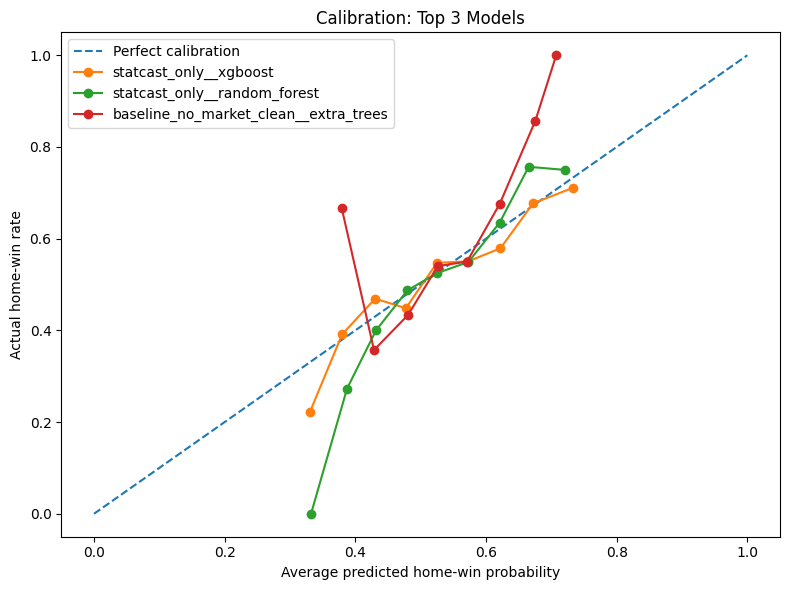

In [31]:
plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

for model_name in top_model_names:
    plot_df = calib_table_all[
        (calib_table_all["model_name"] == model_name) &
        (calib_table_all["games"] > 0)
    ].dropna(subset=["avg_pred_prob", "actual_home_win_rate"])

    plt.plot(
        plot_df["avg_pred_prob"],
        plot_df["actual_home_win_rate"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Average predicted home-win probability")
plt.ylabel("Actual home-win rate")
plt.title("Calibration: Top 3 Models")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import numpy as np

TARGET_COL = "target_home_win"

LEAKY_COLS_EXACT = {
    "home_score",
    "away_score",
    "diff_score",
    "home_margin",
    "target_home_win",
}

metadata_cols = {
    "game_pk",
    "run_id",
    "scored_at_utc",
    "official_date",
    "official_date_dt",
    "game_datetime_utc",
    "home_team_name",
    "away_team_name",
    "home_team_id",
    "away_team_id",
    "venue_name",
    "abstract_state",
    "detailed_state",
}

def is_probably_leaky_feature(col: str) -> bool:
    c = col.lower()

    if c in LEAKY_COLS_EXACT:
        return True

    hard_patterns = [
        "winner",
        "winning",
        "losing",
        "final",
        "result",
        "outcome",
        "actual",
        "post_",
    ]

    if any(p in c for p in hard_patterns):
        return True

    if c.endswith("_id") or c in metadata_cols:
        return True

    return False


# Recreate completed_i if needed
if "completed_i" not in globals():
    completed_i = features[features[TARGET_COL].notna()].copy()
    completed_i["official_date"] = pd.to_datetime(completed_i["official_date"])
    completed_i[TARGET_COL] = completed_i[TARGET_COL].astype(int)

    # Optional: keep 2023+ only
    MIN_TRAIN_DATE = "2023-01-01"
    completed_i = completed_i[completed_i["official_date"] >= MIN_TRAIN_DATE].copy()

# Build numeric candidate columns
candidate_feature_cols = [
    c for c in completed_i.columns
    if c not in metadata_cols
    and c != TARGET_COL
    and pd.api.types.is_numeric_dtype(completed_i[c])
]

# Remove leakage
clean_feature_cols = [
    c for c in candidate_feature_cols
    if not is_probably_leaky_feature(c)
]

print("Candidate feature count:", len(candidate_feature_cols))
print("Clean feature count:", len(clean_feature_cols))

removed_features = sorted(set(candidate_feature_cols) - set(clean_feature_cols))
display(pd.Series(removed_features, name="removed_features").head(100))

Candidate feature count: 1784
Clean feature count: 1776


0                  away_score
1                  diff_score
2                diff_team_id
3                 home_margin
4                  home_score
5    probable_away_pitcher_id
6    probable_home_pitcher_id
7                    venue_id
Name: removed_features, dtype: object

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import ParameterSampler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost unavailable:", repr(e))


def chronological_train_val_test_split(
    df: pd.DataFrame,
    val_frac: float = 0.15,
    test_frac: float = 0.20,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.sort_values(["official_date", "game_datetime_utc", "game_pk"]).reset_index(drop=True)

    n = len(df)
    test_start = int(n * (1 - test_frac))
    val_start = int(test_start * (1 - val_frac))

    train = df.iloc[:val_start].copy()
    val = df.iloc[val_start:test_start].copy()
    test = df.iloc[test_start:].copy()

    return train, val, test


# Prefer the currently winning feature family.
# Fall back to all clean features if feature_sets is unavailable.
preferred_feature_set = "statcast_only"

if "feature_sets" in globals() and preferred_feature_set in feature_sets:
    xgb_cols = [
        c for c in feature_sets[preferred_feature_set]
        if c in clean_feature_cols and c in completed_i.columns
    ]
else:
    xgb_cols = [
        c for c in clean_feature_cols
        if c in completed_i.columns
        and (
            "statcast" in c.lower()
            or "_sc_" in c.lower()
            or "batted_ball" in c.lower()
            or "distance" in c.lower()
            or "avg_ev" in c.lower()
        )
    ]

print("Tuning feature set:", preferred_feature_set)
print("Feature count:", len(xgb_cols))

assert len(xgb_cols) > 0, "No XGBoost feature columns found. Check feature_sets or clean_feature_cols."

print("Tuning feature set:", preferred_feature_set)
print("Feature count:", len(xgb_cols))

xgb_train_df, xgb_val_df, xgb_test_df = chronological_train_val_test_split(
    completed_i,
    val_frac=0.15,
    test_frac=0.20,
)

print("Train:", len(xgb_train_df), xgb_train_df["official_date"].min(), "to", xgb_train_df["official_date"].max())
print("Val:  ", len(xgb_val_df), xgb_val_df["official_date"].min(), "to", xgb_val_df["official_date"].max())
print("Test: ", len(xgb_test_df), xgb_test_df["official_date"].min(), "to", xgb_test_df["official_date"].max())

X_train_raw = xgb_train_df[xgb_cols].copy()
X_val_raw = xgb_val_df[xgb_cols].copy()
X_test_raw = xgb_test_df[xgb_cols].copy()

y_train = xgb_train_df[TARGET_COL].astype(int)
y_val = xgb_val_df[TARGET_COL].astype(int)
y_test = xgb_test_df[TARGET_COL].astype(int)

# XGBoost can handle NaN natively, but using the same imputation structure
# as your model lab keeps comparisons consistent.
imputer = SimpleImputer(strategy="median", add_indicator=True)
X_train = imputer.fit_transform(X_train_raw)
X_val = imputer.transform(X_val_raw)
X_test = imputer.transform(X_test_raw)

Tuning feature set: statcast_only
Feature count: 1099
Tuning feature set: statcast_only
Feature count: 1099
Train: 5565 2023-03-30 00:00:00 to 2025-05-19 00:00:00
Val:   983 2025-05-19 00:00:00 to 2025-08-04 00:00:00
Test:  1637 2025-08-04 00:00:00 to 2026-06-01 00:00:00


In [36]:
assert XGBOOST_AVAILABLE, "Install/import xgboost before running this cell."

RANDOM_STATE = 42
N_ITER = 40  # increase to 75-100 later if runtime is acceptable

param_space = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.02, 0.03, 0.05],
    "min_child_weight": [5, 10, 20, 40],
    "subsample": [0.65, 0.75, 0.85, 0.95],
    "colsample_bytree": [0.50, 0.65, 0.80, 0.95],
    "gamma": [0.0, 0.25, 0.5, 1.0],
    "reg_alpha": [0.0, 0.05, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0],
}

samples = list(ParameterSampler(param_space, n_iter=N_ITER, random_state=RANDOM_STATE))

tuning_rows = []
trained_trials = {}

for i, params in enumerate(samples, start=1):
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_estimators=2500,
        early_stopping_rounds=75,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

    p_val = model.predict_proba(X_val)[:, 1]

    row = {
        "trial": i,
        **params,
        "best_iteration": getattr(model, "best_iteration", np.nan),
        "best_score": getattr(model, "best_score", np.nan),
        "val_log_loss": log_loss(y_val, p_val),
        "val_brier": brier_score_loss(y_val, p_val),
        "val_auc": roc_auc_score(y_val, p_val),
        "val_accuracy_50pct": accuracy_score(y_val, p_val >= 0.5),
        "avg_pred": float(np.mean(p_val)),
        "actual_rate": float(np.mean(y_val)),
    }

    tuning_rows.append(row)
    trained_trials[i] = model

    if i % 5 == 0:
        print(f"Finished {i}/{len(samples)} trials")

tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_log_loss", "val_brier", "val_auc"], ascending=[True, True, False])
display(tuning_df.head(15))

Finished 5/40 trials
Finished 10/40 trials
Finished 15/40 trials
Finished 20/40 trials
Finished 25/40 trials
Finished 30/40 trials
Finished 35/40 trials
Finished 40/40 trials


,trial,subsample,reg_lambda,reg_alpha,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree,best_iteration,best_score,val_log_loss,val_brier,val_auc,val_accuracy_50pct,avg_pred,actual_rate
13,14,0.65,2.0,1.00,40,2,0.05,1.00,0.95,82,0.683619,0.683619,0.245348,0.561100,0.544252,0.530169,0.536114
2,3,0.65,10.0,0.50,20,4,0.01,0.00,0.50,196,0.684591,0.684591,0.245796,0.554296,0.541200,0.527454,0.536114
21,22,0.75,2.0,0.05,10,3,0.03,0.50,0.95,62,0.684615,0.684615,0.245795,0.556035,0.543235,0.527643,0.536114
6,7,0.65,2.0,0.00,10,4,0.05,0.50,0.50,41,0.684801,0.684801,0.245897,0.557151,0.549339,0.527326,0.536114
9,10,0.85,1.0,0.50,20,3,0.02,0.00,0.65,60,0.684906,0.684906,0.245922,0.555873,0.542218,0.526164,0.536114
1,2,0.95,1.0,0.10,10,3,0.01,0.00,0.65,204,0.684921,0.684921,0.245951,0.553435,0.545270,0.527196,0.536114
11,12,0.85,5.0,0.10,20,4,0.03,0.25,0.65,53,0.685169,0.685169,0.246064,0.552602,0.535097,0.527989,0.536114
24,25,0.95,5.0,0.50,5,3,0.05,0.25,0.80,71,0.685222,0.685222,0.246101,0.556464,0.531027,0.527087,0.536114
18,19,0.75,2.0,0.00,10,4,0.02,0.00,0.50,64,0.685258,0.685258,0.246127,0.546003,0.530010,0.525215,0.536114
34,35,0.85,10.0,0.50,5,4,0.05,0.00,0.65,14,0.685312,0.685312,0.246115,0.557267,0.551373,0.526336,0.536114


Best trial: 14
Best params:


max_depth            2.00
learning_rate        0.05
min_child_weight    40.00
subsample            0.65
colsample_bytree     0.95
gamma                1.00
reg_alpha            1.00
reg_lambda           2.00
dtype: float64

Best iteration: 82
Best score: 0.6836193776021533


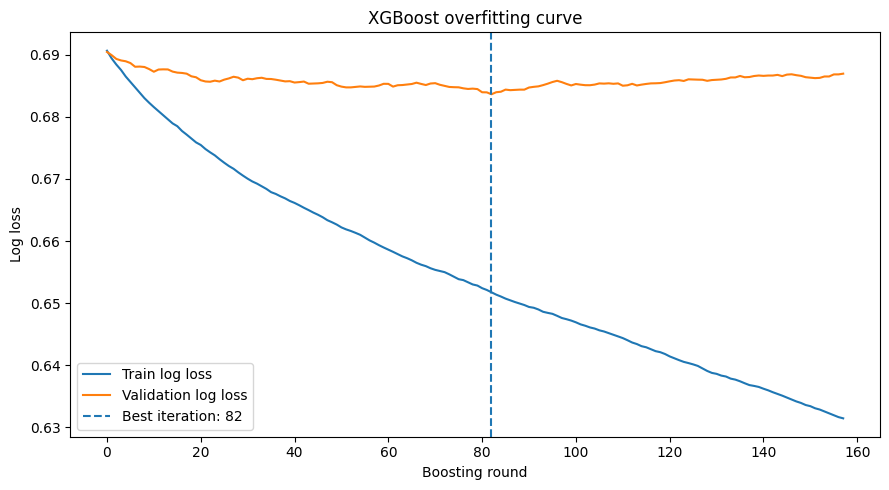

In [37]:
best_trial = int(tuning_df.iloc[0]["trial"])
best_tuned_model = trained_trials[best_trial]
best_params = {
    k: tuning_df.iloc[0][k]
    for k in param_space.keys()
}

print("Best trial:", best_trial)
print("Best params:")
display(pd.Series(best_params))
print("Best iteration:", getattr(best_tuned_model, "best_iteration", None))
print("Best score:", getattr(best_tuned_model, "best_score", None))

evals = best_tuned_model.evals_result()

train_logloss = evals["validation_0"]["logloss"]
val_logloss = evals["validation_1"]["logloss"]

plt.figure(figsize=(9, 5))
plt.plot(train_logloss, label="Train log loss")
plt.plot(val_logloss, label="Validation log loss")

best_iter = getattr(best_tuned_model, "best_iteration", None)
if best_iter is not None:
    plt.axvline(best_iter, linestyle="--", label=f"Best iteration: {best_iter}")

plt.xlabel("Boosting round")
plt.ylabel("Log loss")
plt.title("XGBoost overfitting curve")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
best_n_estimators = int(getattr(best_tuned_model, "best_iteration", 300)) + 1

X_trainval_raw = pd.concat([X_train_raw, X_val_raw], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_imputer = SimpleImputer(strategy="median", add_indicator=True)
X_trainval = final_imputer.fit_transform(X_trainval_raw)
X_test_final = final_imputer.transform(X_test_raw)

final_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=best_n_estimators,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)

final_xgb.fit(X_trainval, y_trainval)

p_test = final_xgb.predict_proba(X_test_final)[:, 1]

tuned_test_metrics = {
    "model_name": "statcast_only__xgboost_tuned",
    "feature_count": len(xgb_cols),
    "n_test": len(y_test),
    "avg_pred": float(np.mean(p_test)),
    "actual_rate": float(np.mean(y_test)),
    "log_loss": float(log_loss(y_test, p_test)),
    "brier": float(brier_score_loss(y_test, p_test)),
    "roc_auc": float(roc_auc_score(y_test, p_test)),
    "accuracy_50pct": float(accuracy_score(y_test, p_test >= 0.5)),
    "best_n_estimators": best_n_estimators,
}

display(pd.DataFrame([tuned_test_metrics]))

print("\nClassification report:")
print(classification_report(y_test, (p_test >= 0.5).astype(int), digits=3))

display(pd.DataFrame(
    confusion_matrix(y_test, (p_test >= 0.5).astype(int)),
    index=["actual_away", "actual_home"],
    columns=["pred_away", "pred_home"],
))

XGBoostError: Invalid Parameter format for max_depth expect int but value='2.0'

In [ ]:
calib_tuned = pd.DataFrame({"p": p_test, "y": y_test.values})
calib_tuned["bucket"] = pd.cut(
    calib_tuned["p"],
    bins=[0, .35, .40, .45, .50, .55, .60, .65, .70, 1.0],
    include_lowest=True,
)

calib_tuned_table = (
    calib_tuned
    .groupby("bucket", observed=False)
    .agg(
        games=("y", "size"),
        avg_pred_prob=("p", "mean"),
        actual_home_win_rate=("y", "mean"),
    )
)

calib_tuned_table["calibration_error"] = (
    calib_tuned_table["actual_home_win_rate"] - calib_tuned_table["avg_pred_prob"]
)

display(calib_tuned_table)

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plot_df = calib_tuned_table.dropna()
plt.plot(
    plot_df["avg_pred_prob"],
    plot_df["actual_home_win_rate"],
    marker="o",
    label="Tuned XGBoost",
)
plt.xlabel("Average predicted home-win probability")
plt.ylabel("Actual home-win rate")
plt.title("Calibration: Tuned XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Permutation importance

This can be slow. It uses the holdout period only and scores by negative log loss.

In [20]:
RUN_PERMUTATION_IMPORTANCE = True

if RUN_PERMUTATION_IMPORTANCE:
    X_test_best = test_df[best_cols].copy()
    perm = permutation_importance(
        best_model,
        X_test_best,
        y_test,
        scoring="neg_log_loss",
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
    )
    imp = pd.DataFrame({
        "feature": best_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)
    display(imp.head(100))
else:
    print("Permutation importance skipped. Set RUN_PERMUTATION_IMPORTANCE = True to run it.")

,feature,importance_mean,importance_std
1027,diff_bullpen_sc_woba_allowed_season_to_date,0.001159,0.000789
807,diff_starter_statcast_sc_k_rate_season_to_date,0.000986,0.000367
1058,diff_bullpen_sc_release_spin_mean_last1,0.000705,0.000500
230,diff_team_off_sc_bb_rate_season_to_date,0.000549,0.000408
165,diff_team_off_sc_pitches_seen_season_to_date,0.000526,0.000307
169,diff_team_off_sc_pitches_seen_last40,0.000449,0.000166
789,diff_starter_statcast_sc_avg_la_allowed_last5,0.000425,0.000122
464,home_starter_statcast_sc_release_extension_mea...,0.000305,0.000490
548,home_starter_statcast_sc_k_rate_last3,0.000297,0.000127
97,away_team_off_sc_woba_last10,0.000278,0.000324


## 15. Optional champion export

Set `APPROVE_EXPORT = True` only after:

- Leakage audit shows no impossible features.
- Champion metrics are not suspicious.
- Calibration looks reasonable.
- The champion beats the constant home-rate baseline on log loss and Brier.

The exported bundle contains the fitted model and the exact feature columns required by production scoring.

In [19]:
APPROVE_EXPORT = False

best_metrics = results_df[results_df["model_name"].eq(best_name)].iloc[0].to_dict()
constant_metrics = results_df[results_df["model_name"].eq("constant_train_home_rate")].iloc[0].to_dict()

beats_baseline = (
    best_metrics["log_loss"] < constant_metrics["log_loss"] and
    best_metrics["brier"] < constant_metrics["brier"]
)

print("Best model:", best_name)
print("Beats constant baseline on log loss and Brier:", beats_baseline)
print("Best metrics:", best_metrics)
print("Constant baseline metrics:", constant_metrics)

if APPROVE_EXPORT:
    assert not best_metrics["suspicious_metric"], "Refusing export: champion metrics are suspicious."
    assert beats_baseline, "Refusing export: champion does not beat constant baseline on log loss and Brier."

    import joblib

    bundle = {
        "model": best_model,
        "feature_cols": best_cols,
        "model_name": best_name,
        "metrics": best_metrics,
        "target_col": TARGET_COL,
        "min_train_date": MIN_TRAIN_DATE,
        "max_train_date": MAX_TRAIN_DATE,
        "train_start": str(train_df["official_date"].min()),
        "train_end": str(train_df["official_date"].max()),
        "test_start": str(test_df["official_date"].min()),
        "test_end": str(test_df["official_date"].max()),
        "created_from_features_path": str(FEATURES_PATH),
        "leakage_removed_cols": leakage_removed_cols,
        "missing_removed_cols": missing_removed_cols,
    }

    model_path = MODEL_DIR / "mlb_moneyline_champion.joblib"
    metadata_path = MODEL_DIR / "mlb_moneyline_champion_metadata.json"

    joblib.dump(bundle, model_path)

    metadata = {k: v for k, v in bundle.items() if k != "model"}
    metadata_path.write_text(json.dumps(metadata, default=str, indent=2))

    print("Saved:", model_path)
    print("Saved:", metadata_path)
else:
    print("APPROVE_EXPORT is False; not exporting.")

Best model: statcast_only__xgboost
Beats constant baseline on log loss and Brier: True
Best metrics: {'model_name': 'statcast_only__xgboost', 'feature_count': 1099, 'n_test': 1637, 'avg_pred': 0.5371366143226624, 'actual_rate': 0.529627367135003, 'log_loss': 0.6814268130134843, 'brier': 0.2442423080618941, 'roc_auc': 0.5778876256384906, 'accuracy_50pct': 0.5656689065363469, 'suspicious_metric': False}
Constant baseline metrics: {'model_name': 'constant_train_home_rate', 'feature_count': 0, 'n_test': 1637, 'avg_pred': 0.5284056200366524, 'actual_rate': 0.529627367135003, 'log_loss': 0.6913935852947655, 'brier': 0.24912371178262008, 'roc_auc': 0.5, 'accuracy_50pct': 0.529627367135003, 'suspicious_metric': False}
APPROVE_EXPORT is False; not exporting.


## 16. Upload champion model to GCS after export

After setting `APPROVE_EXPORT = True` and rerunning the export cell, upload the files from Cloud Shell or your local terminal:

```bash
export PROJECT_ID="tetheredai-preds"
export BUCKET="tetheredai-mlb-state-${PROJECT_ID}"

cd ~/TetheredAI/MLB/mlb_betting_app

gcloud storage cp models/mlb_moneyline_champion.joblib   "gs://${BUCKET}/mlb/models/mlb_moneyline_champion.joblib"

gcloud storage cp models/mlb_moneyline_champion_metadata.json   "gs://${BUCKET}/mlb/models/mlb_moneyline_champion_metadata.json"
```

Then run the daily scoring Cloud Run job.